In [19]:
from pathlib import Path
ROOT = Path.cwd().parent
RUNS_DIR = ROOT / ".runs"

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------------
# Configuration
# --------------------------------------------------

EXPERIMENT_DIRS = {
    "ViT": RUNS_DIR / "vit",
    "DeIT": RUNS_DIR / "deit",
    "WiderResnet": RUNS_DIR / "wrn",
}

In [27]:
# --------------------------------------------------
# Utilities
# --------------------------------------------------

def load_runs(directory):
    """
    Load all CSV files from a directory.

    Returns:
        dict[str, pd.DataFrame]
            {run_name: dataframe}
    """
    runs = {}

    for csv_file in sorted(directory.glob("logs/*.csv")):
        runs[csv_file.stem] = pd.read_csv(csv_file)

    return runs


def load_all_experiments(experiment_dirs):
    """
    Load all experiments.

    Returns:
        dict[str, dict[str, pd.DataFrame]]
            {
                "ViT": {...},
                "DeIT": {...},
                ...
            }
    """
    experiments = {}

    for label, directory in experiment_dirs.items():
        experiments[label] = load_runs(directory)

    return experiments


# --------------------------------------------------
# Single run plots
# --------------------------------------------------

def plot_run(df, title):
    """
    Plot loss and accuracy for a single run.
    """

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Loss
    axes[0].plot(df["epoch"], df["train_loss"], label="train_loss")
    axes[0].plot(df["epoch"], df["val_loss"], label="val_loss")
    axes[0].set_title(f"{title} - Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].grid(True)
    axes[0].legend()

    # Accuracy
    axes[1].plot(df["epoch"], df["val_acc"], label="val_acc")
    axes[1].plot(df["epoch"], df["best_acc"], label="best_acc")
    axes[1].set_title(f"{title} - Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy (%)")
    axes[1].grid(True)
    axes[1].legend()

    plt.tight_layout()
    plt.show()


def plot_all_runs(experiments):
    """
    Plot every CSV individually.
    """

    for model_name, runs in experiments.items():
        for run_name, df in runs.items():
            plot_run(df, f"{model_name} / {run_name}")


# --------------------------------------------------
# Comparison plots
# --------------------------------------------------

def plot_metric_comparison(experiments, metric):
    """
    Plot one metric for all runs.

    Example metrics:
        val_acc
        best_acc
        train_loss
        val_loss
    """

    plt.figure(figsize=(12, 6))

    for model_name, runs in experiments.items():
        for run_name, df in runs.items():

            label = f"{model_name} - {run_name}"

            plt.plot(
                df["epoch"],
                df[metric],
                label=label,
                linewidth=2,
            )

    plt.title(metric)
    plt.xlabel("Epoch")
    plt.ylabel(metric)
    plt.grid(True)
    plt.legend()
    plt.show()


# --------------------------------------------------
# Best run per architecture
# --------------------------------------------------

def get_best_run(runs):
    """
    Returns (run_name, dataframe, best_accuracy)
    """

    best_name = None
    best_df = None
    best_acc = -1

    for run_name, df in runs.items():

        run_best = df["best_acc"].max()

        if run_best > best_acc:
            best_acc = run_best
            best_name = run_name
            best_df = df

    return best_name, best_df, best_acc


def plot_best_runs(experiments):
    """
    Compare only the best run of each architecture.
    """

    plt.figure(figsize=(10, 5))

    for model_name, runs in experiments.items():

        run_name, df, best_acc = get_best_run(runs)

        plt.plot(
            df["epoch"],
            df["val_acc"],
            label=f"{model_name} ({best_acc:.2f}%)",
            linewidth=3,
        )

    plt.title("Best Validation Accuracy per Architecture")
    plt.xlabel("Epoch")
    plt.ylabel("Validation Accuracy (%)")
    plt.grid(True)
    plt.legend()
    plt.show()




In [28]:
def create_results_table(experiments):
    """
    Create a summary dataframe with one row per run.
    """

    rows = []

    for model_name, runs in experiments.items():

        for run_name, df in runs.items():

            final_row = df.iloc[-1]

            rows.append({
                "Architecture": model_name,
                "Run": run_name,
                "Best Acc": df["best_acc"].max(),
                "Final Val Acc": final_row["val_acc"],
                "Final Val Loss": final_row["val_loss"],
                "Final Train Loss": final_row["train_loss"],
                "Epochs": len(df),
            })

    results = pd.DataFrame(rows)

    return results.sort_values(
        by="Best Acc",
        ascending=False
    ).reset_index(drop=True)

In [29]:
experiments = load_all_experiments(EXPERIMENT_DIRS)

In [30]:
create_results_table(experiments)

,Architecture,Run,Best Acc,Final Val Acc,Final Val Loss,Final Train Loss,Epochs
0,WiderResnet,metrics,96.59,96.50,0.285673,1.044480,300
1,DeIT,metrics,93.15,93.15,0.253332,0.547177,300
2,ViT,metrics,89.55,89.26,0.429522,1.060269,300


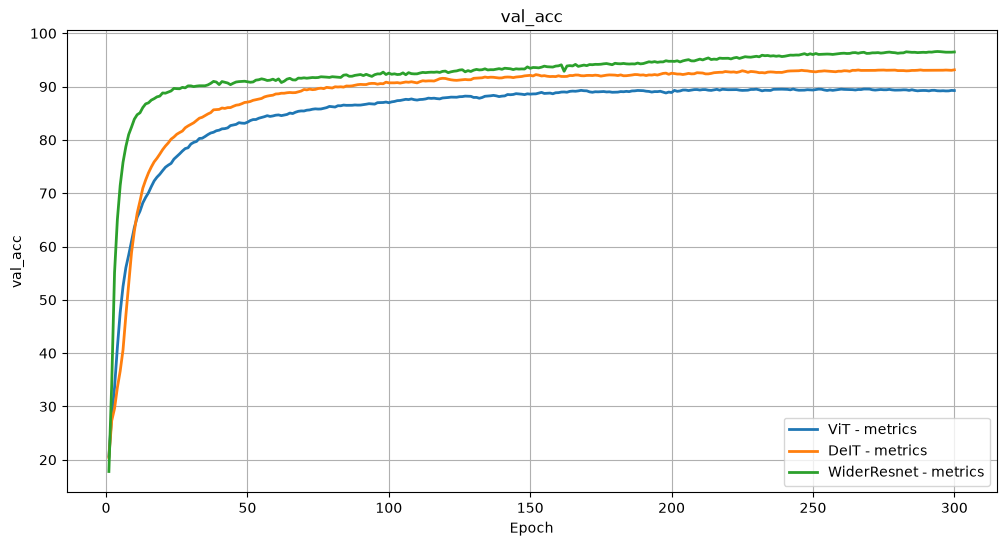

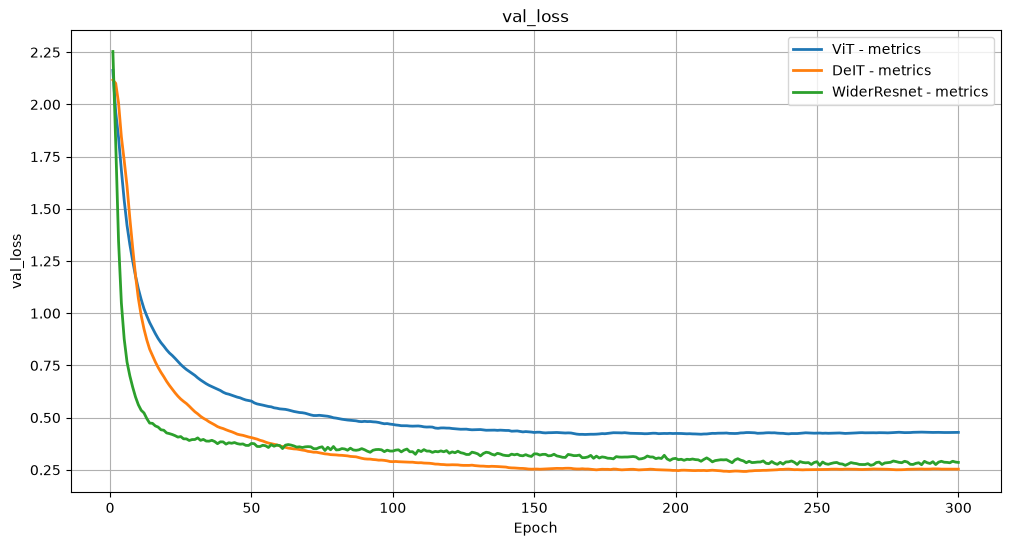

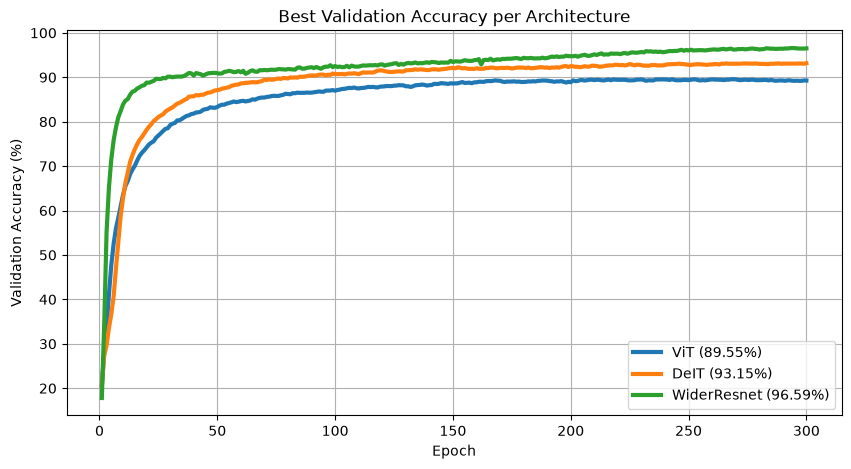

In [31]:
# Compare all runs
plot_metric_comparison(experiments, "val_acc")
plot_metric_comparison(experiments, "val_loss")

# Compare best run of each architecture
plot_best_runs(experiments)